<span style="color:Red">
    
# TASK 4.0 NEURAL NETWORKS
    
</span>

## Dino Teeth Classification using Neural Networks (From Scratch)

## Objective
Build a neural network from scratch (without TensorFlow/PyTorch) to classify dinosaur teeth images into respective classes.

## Dataset
- Training: Janak’s Secret Samples
- Testing: Tim’s Kins

This is a supervised multi-class classification problem using image data.

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
print("Imported successfully")

Imported successfully


## Structure

Input (flattened image)

 → Hidden Layer 1 (ReLU)
 
 → Hidden Layer 2 (ReLU)
 
 → Output Layer (Softmax)
 
 → Cross-Entropy Loss
 
 → Backpropagation


## STEP 1. Dataset Handling & Preprocessing

### 1.1 Unzip the Files

In [68]:
import zipfile
import os

# unzip training data
with zipfile.ZipFile("Train.zip", 'r') as zip_ref:
    zip_ref.extractall("train")

# unzip test data
with zipfile.ZipFile("Test.zip", 'r') as zip_ref:
    zip_ref.extractall("test")


This creates two folders:
train/ and test/

In [69]:
print(os.listdir("train"))


['Train']


In [70]:
print(os.listdir("train/Train"))


['Jade', 'James', 'Jane', 'Joel', 'Jovi']


### 1.2  Label Encoding

In [71]:
import os

train_dir = "train/Train"

class_names = sorted(os.listdir(train_dir))

label_map = {class_name: idx for idx, class_name in enumerate(class_names)}
print(label_map)



{'Jade': 0, 'James': 1, 'Jane': 2, 'Joel': 3, 'Jovi': 4}


## 1.3 Image Loading & Preprocessing

In [72]:
from PIL import Image
import numpy as np

def load_and_preprocess_image(img_path, img_size=(64, 64)):
    img = Image.open(img_path).convert("L")  # grayscale
    img = img.resize(img_size)
    img_array = np.array(img)
    img_array = img_array / 255.0            # normalize
    return img_array.flatten()               # flatten


Why grayscale?

Teeth shape > color

Less parameters

Faster training

In [73]:
X_train = []
y_train = []

for class_name in class_names:
    class_folder = os.path.join(train_dir, class_name)
    
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        
        X_train.append(load_and_preprocess_image(img_path))
        y_train.append(label_map[class_name])


In [74]:
X_train = np.array(X_train)
y_train = np.array(y_train)


In [75]:
def one_hot_encode(y, num_classes):
    one_hot = np.zeros((y.size, num_classes))
    one_hot[np.arange(y.size), y] = 1
    return one_hot

y_train_oh = one_hot_encode(y_train, num_classes=len(class_names))


In [76]:
X_train.shape

(4000, 4096)

In [77]:
y_train_oh.shape


(4000, 5)

## STEP 2 :Neural Network From Scratch

In [78]:
def relu(Z):
    return np.maximum(0, Z)


In [79]:
def relu_derivative(Z):
    return (Z > 0).astype(float)


In [80]:
def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)


In [81]:
def cross_entropy_loss(y_true, y_pred):
    m = y_true.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / m
    return loss


In [82]:
class NeuralNetwork:
    def __init__(self, input_size, hidden1, hidden2, output_size, lr=0.01):
        self.lr = lr

        # Weights
        self.W1 = np.random.randn(input_size, hidden1) * 0.01
        self.b1 = np.zeros((1, hidden1))

        self.W2 = np.random.randn(hidden1, hidden2) * 0.01
        self.b2 = np.zeros((1, hidden2))

        self.W3 = np.random.randn(hidden2, output_size) * 0.01
        self.b3 = np.zeros((1, output_size))

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = relu(self.Z1)

        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = relu(self.Z2)

        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        self.A3 = softmax(self.Z3)

        return self.A3

    def backward(self, X, y_true):
        m = X.shape[0]

        dZ3 = self.A3 - y_true
        dW3 = np.dot(self.A2.T, dZ3) / m
        db3 = np.sum(dZ3, axis=0, keepdims=True) / m

        dA2 = np.dot(dZ3, self.W3.T)
        dZ2 = dA2 * relu_derivative(self.Z2)
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * relu_derivative(self.Z1)
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # Update weights
        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs=300):
        losses = []
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = cross_entropy_loss(y, y_pred)
            losses.append(loss)   
            self.backward(X, y)
            if epoch % 50 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
        return losses


    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)





## STEP 3: Training the Neural Network

### 3.1 Initialize the model

In [83]:
input_size = X_train.shape[1]      # should be 4096 if 64x64
output_size = y_train_oh.shape[1]  # should be 5

print(input_size, output_size)


4096 5


In [84]:
nn = NeuralNetwork(
    input_size=input_size,
    hidden1=128,
    hidden2=64,
    output_size=output_size,
    lr=0.03
)


### 3.2 Train the model

In [87]:
 losses = nn.train(X_train, y_train_oh, epochs=800)


Epoch 0, Loss: 0.1162
Epoch 50, Loss: 0.1142
Epoch 100, Loss: 0.1124
Epoch 150, Loss: 0.1108
Epoch 200, Loss: 0.1092
Epoch 250, Loss: 0.1077
Epoch 300, Loss: 0.1063
Epoch 350, Loss: 0.1049
Epoch 400, Loss: 0.1036
Epoch 450, Loss: 0.1023
Epoch 500, Loss: 0.1011
Epoch 550, Loss: 0.0999
Epoch 600, Loss: 0.0987
Epoch 650, Loss: 0.0976
Epoch 700, Loss: 0.0965
Epoch 750, Loss: 0.0955


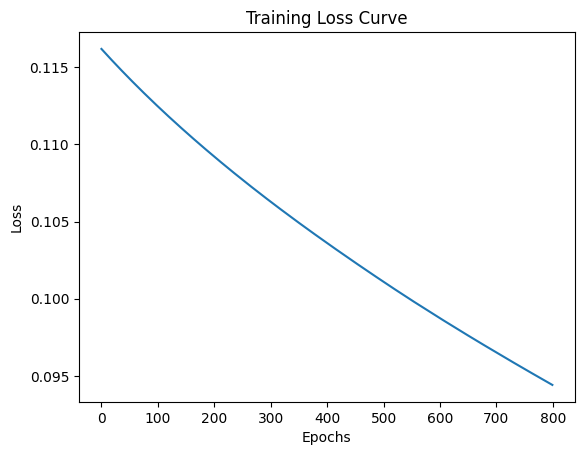

In [88]:
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

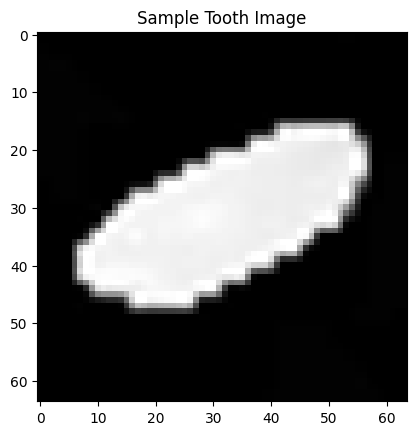

In [30]:
plt.imshow(X_train[0].reshape(64,64), cmap='gray')
plt.title("Sample Tooth Image")
plt.show()

### 3.3 Evaluate Training Accuracy

In [22]:
train_preds = nn.predict(X_train)
true_labels = np.argmax(y_train_oh, axis=1)

accuracy = np.mean(train_preds == true_labels)
print(f"Training Accuracy: {accuracy * 100:.2f}%")


Training Accuracy: 89.28%


In [23]:
print(os.listdir("test"))


['Test']


## STEP 4: Test The Model

In [25]:
test_dir = "test/Test"   

X_test = []
y_test = []

for class_name in class_names:
    class_folder = os.path.join(test_dir, class_name)
    
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        X_test.append(load_and_preprocess_image(img_path))
        y_test.append(label_map[class_name])

X_test = np.array(X_test)
y_test = np.array(y_test)


In [26]:
test_preds = nn.predict(X_test)

In [27]:
test_accuracy = np.mean(test_preds == y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Test Accuracy: 88.30%


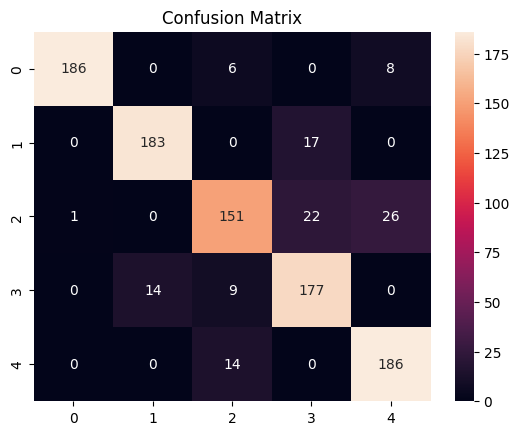

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, test_preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()